In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [3]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
sample_submission = pd.read_csv('sample_submission.csv')

In [4]:
print(train.head())
print(train.shape)

          id product_code  product_weight_kg fat_content  shelf_visibility  \
0  row_00000   PRD-PRFP9S             14.252     Low Fat            0.0271   
1  row_00001   PRD-PXXK71              7.698     Low Fat            0.0720   
2  row_00002   PRD-V5MOIJ             14.264     Regular            0.0421   
3  row_00003   PRD-UN5Z3J                NaN     Regular            0.0449   
4  row_00004   PRD-6RDQYB             10.338     Regular            0.0120   

     product_category  product_price store_code  store_age_years store_size  \
0        Frozen Foods          81.37  STORE-AGY               45      Large   
1  HEALTH AND HYGIENE          42.05  STORE-YLW               35      Small   
2              Canned          41.35  STORE-89Z               33     Medium   
3         soft drinks         174.35  STORE-7WS               47     Medium   
4                meat         203.06  STORE-9RG               28      Small   

  store_location_tier          store_format  total_sales

In [5]:
print(test.head())
print(test.shape)

          id product_code  product_weight_kg fat_content  shelf_visibility  \
0  row_00009   PRD-2WLNC8              8.628     Low Fat            0.0167   
1  row_00015   PRD-LV9PLM              6.993     Low Fat            0.0579   
2  row_00019   PRD-ET6ZI7                NaN     Low Fat            0.1262   
3  row_00020   PRD-6RX35U             14.034     Regular            0.0761   
4  row_00023   PRD-I4J38V             13.063     Low Fat            0.0650   

        product_category  product_price store_code  store_age_years  \
0              household         190.72  STORE-HL7               23   
1     Health and Hygiene         261.07  STORE-9RG               28   
2  FRUITS AND VEGETABLES         112.50  STORE-7WS               47   
3           frozen foods         200.71  STORE-DKU               30   
4           Frozen Foods         150.59  STORE-89Z               33   

  store_size store_location_tier          store_format  
0     Medium              Tier_3            Sup

In [6]:
sample_submission.head()

,id,total_sales
0,row_00009,2174.76
1,row_00015,2174.76
2,row_00019,2174.76
3,row_00020,2174.76
4,row_00023,2174.76


In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6818 entries, 0 to 6817
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   6818 non-null   object 
 1   product_code         6818 non-null   object 
 2   product_weight_kg    5593 non-null   float64
 3   fat_content          6818 non-null   object 
 4   shelf_visibility     6818 non-null   float64
 5   product_category     6818 non-null   object 
 6   product_price        6818 non-null   float64
 7   store_code           6818 non-null   object 
 8   store_age_years      6818 non-null   int64  
 9   store_size           4899 non-null   object 
 10  store_location_tier  6818 non-null   object 
 11  store_format         6818 non-null   object 
 12  total_sales          6818 non-null   float64
dtypes: float64(4), int64(1), object(8)
memory usage: 692.6+ KB


In [8]:
train.columns.tolist()

['id',
 'product_code',
 'product_weight_kg',
 'fat_content',
 'shelf_visibility',
 'product_category',
 'product_price',
 'store_code',
 'store_age_years',
 'store_size',
 'store_location_tier',
 'store_format',
 'total_sales']

In [9]:
test.columns.tolist()

['id',
 'product_code',
 'product_weight_kg',
 'fat_content',
 'shelf_visibility',
 'product_category',
 'product_price',
 'store_code',
 'store_age_years',
 'store_size',
 'store_location_tier',
 'store_format']

In [10]:
train["product_category"].value_counts()

product_category
Fruits and Vegetables    480
Snack Foods              468
Household                387
Frozen Foods             326
Canned                   271
Dairy                    269
fruits and vegetables    265
FRUITS AND VEGETABLES    261
Baking Goods             254
snack foods              236
SNACK FOODS              229
Health and Hygiene       197
HOUSEHOLD                185
Soft Drinks              178
frozen foods             177
FROZEN FOODS             172
household                168
Meat                     157
DAIRY                    143
dairy                    142
BAKING GOODS             137
canned                   129
baking goods             125
CANNED                   117
health and hygiene       116
Breads                   110
SOFT DRINKS              100
HEALTH AND HYGIENE        99
MEAT                      94
Hard Drinks               92
meat                      88
soft drinks               88
Others                    73
Starchy Foods             

In [11]:
#checking for missing values in the train dataset
train.isnull().sum()

id                        0
product_code              0
product_weight_kg      1225
fat_content               0
shelf_visibility          0
product_category          0
product_price             0
store_code                0
store_age_years           0
store_size             1919
store_location_tier       0
store_format              0
total_sales               0
dtype: int64

In [12]:
train.groupby('store_format')['store_size'].apply(lambda x: x.isnull().mean())

store_format
Corner Shop             0.506928
Flagship Hypermarket    0.000000
Standard Supermarket    0.331690
Superstore              0.000000
Name: store_size, dtype: float64

In [13]:
   train['store_size'].value_counts()

store_size
Medium    2218
Small     1933
Large      748
Name: count, dtype: int64

In [14]:
#imputing missing values in the store_size column with a fourth category called "Missing"
train['store_size'] = train['store_size'].fillna('Missing')
test['store_size'] = test['store_size'].fillna('Missing')

In [15]:
#checking to see if the missing values have been imputed
train['store_size'].value_counts()

store_size
Medium     2218
Small      1933
Missing    1919
Large       748
Name: count, dtype: int64

In [16]:
test["store_size"].value_counts()

store_size
Medium     575
Missing    491
Small      455
Large      184
Name: count, dtype: int64

In [17]:

train.groupby('product_category')['product_weight_kg'].apply(lambda x: x.isnull().mean())

product_category
BAKING GOODS             0.204380
BREADS                   0.177778
BREAKFAST                0.052632
Baking Goods             0.165354
Breads                   0.254545
Breakfast                0.121951
CANNED                   0.136752
Canned                   0.188192
DAIRY                    0.083916
Dairy                    0.178439
FROZEN FOODS             0.156977
FRUITS AND VEGETABLES    0.176245
Frozen Foods             0.177914
Fruits and Vegetables    0.191667
HARD DRINKS              0.194444
HEALTH AND HYGIENE       0.171717
HOUSEHOLD                0.156757
Hard Drinks              0.108696
Health and Hygiene       0.208122
Household                0.180879
MEAT                     0.170213
Meat                     0.222930
OTHERS                   0.200000
Others                   0.219178
SEAFOOD                  0.214286
SNACK FOODS              0.152838
SOFT DRINKS              0.180000
STARCHY FOODS            0.100000
Seafood                  0.1666

In [18]:
#Dealing with incomsistent casing in the product_category column
train['product_category'] = train['product_category'].str.lower().str.strip()
test['product_category'] = test['product_category'].str.lower().str.strip()

In [19]:
train["product_category"].unique()

array(['frozen foods', 'health and hygiene', 'canned', 'soft drinks',
       'meat', 'snack foods', 'baking goods', 'household', 'dairy',
       'fruits and vegetables', 'breakfast', 'breads', 'seafood',
       'others', 'hard drinks', 'starchy foods'], dtype=object)

In [20]:
train["product_category"].value_counts()

product_category
fruits and vegetables    1006
snack foods               933
household                 740
frozen foods              675
dairy                     554
canned                    517
baking goods              516
health and hygiene        412
soft drinks               366
meat                      339
breads                    209
hard drinks               169
others                    132
starchy foods             113
breakfast                  85
seafood                    52
Name: count, dtype: int64

In [21]:
train['product_category'].apply(lambda x: len(x) != len(x.strip())).sum()

0

In [22]:
# before cleaning
raw = pd.read_csv('train.csv')
print(raw['product_category'].nunique())

# after cleaning
print(train['product_category'].nunique())

48
16


In [23]:
train.groupby('product_category')['product_weight_kg'].apply(lambda x: x.isnull().mean())

product_category
baking goods             0.174419
breads                   0.215311
breakfast                0.141176
canned                   0.176015
dairy                    0.173285
frozen foods             0.173333
fruits and vegetables    0.184891
hard drinks              0.142012
health and hygiene       0.182039
household                0.175676
meat                     0.194690
others                   0.181818
seafood                  0.250000
snack foods              0.186495
soft drinks              0.177596
starchy foods            0.150442
Name: product_weight_kg, dtype: float64

In [24]:
test["product_category"].value_counts()

product_category
snack foods              267
fruits and vegetables    226
frozen foods             181
household                170
baking goods             132
canned                   132
dairy                    128
health and hygiene       108
meat                      86
soft drinks               79
hard drinks               45
breads                    42
others                    37
starchy foods             35
breakfast                 25
seafood                   12
Name: count, dtype: int64

In [25]:
train.groupby('product_category')['product_weight_kg'].agg(['mean', 'median', 'std', 'skew'])

,mean,median,std,skew
product_category,,,,
baking goods,12.286099,11.4980,4.829742,0.291738
breads,11.274957,10.5585,4.453219,0.175240
breakfast,12.791726,10.9950,5.029007,0.389488
canned,12.340833,12.2445,4.510410,0.181551
dairy,13.464902,13.3555,4.725999,-0.063073
frozen foods,12.812946,12.8100,4.484677,0.049252
fruits and vegetables,13.181700,13.0875,4.579492,0.014406
hard drinks,11.216986,9.5660,4.264932,0.576135
health and hygiene,13.115944,12.0630,4.538746,0.090058


In [26]:
#imputing missing values in the product_weight_kg column with the median weight of each product category
category_medians = train.groupby('product_category')['product_weight_kg'].median()

train['product_weight_kg'] = train['product_weight_kg'].fillna(
    train['product_category'].map(category_medians)
)
test['product_weight_kg'] = test['product_weight_kg'].fillna(
    test['product_category'].map(category_medians)
)

In [27]:
print(train.isnull().sum())
print(test.isnull().sum())

id                     0
product_code           0
product_weight_kg      0
fat_content            0
shelf_visibility       0
product_category       0
product_price          0
store_code             0
store_age_years        0
store_size             0
store_location_tier    0
store_format           0
total_sales            0
dtype: int64
id                     0
product_code           0
product_weight_kg      0
fat_content            0
shelf_visibility       0
product_category       0
product_price          0
store_code             0
store_age_years        0
store_size             0
store_location_tier    0
store_format           0
dtype: int64


In [28]:
#checking the other categorical columns for inconsistencies
for col in ['fat_content', 'store_location_tier', 'store_format']:
    print(col)
    print(sorted(train[col].unique()))
    print()

fat_content
['Low Fat', 'Regular']

store_location_tier
['Tier_1', 'Tier_2', 'Tier_3']

store_format
['Corner Shop', 'Flagship Hypermarket', 'Standard Supermarket', 'Superstore']



In [29]:
#examining the target variable
train['total_sales'].describe()

count     6818.000000
mean      2174.756574
std       1697.894956
min         32.700000
25%        834.792500
50%       1790.890000
75%       3092.587500
max      12996.820000
Name: total_sales, dtype: float64

In [30]:
train['total_sales'].skew()

1.1539947519138116

In [31]:
train.groupby('store_format')['total_sales'].agg(['mean', 'median', 'count'])
train.groupby('store_location_tier')['total_sales'].agg(['mean', 'median', 'count'])
train.groupby('store_size')['total_sales'].agg(['mean', 'median', 'count'])
train.groupby('fat_content')['total_sales'].agg(['mean', 'median', 'count'])
train.groupby('product_category')['total_sales'].agg(['mean', 'median', 'count'])

,mean,median,count
product_category,,,
baking goods,1943.416860,1576.380,516
breads,2186.152871,1835.280,209
breakfast,1852.197765,1423.570,85
canned,2196.398743,1838.800,517
dairy,2238.317076,1695.955,554
frozen foods,2140.770133,1704.770,675
fruits and vegetables,2277.854672,1816.565,1006
hard drinks,2189.723195,1842.880,169
health and hygiene,1996.266044,1662.100,412


In [32]:
#checking the correlation between the numerical features and the target variable
numeric_cols = ['product_weight_kg', 'shelf_visibility', 'product_price', 'store_age_years']
train[numeric_cols + ['total_sales']].corr()['total_sales']

product_weight_kg    0.011131
shelf_visibility    -0.118124
product_price        0.569833
store_age_years      0.039443
total_sales          1.000000
Name: total_sales, dtype: float64

<Axes: xlabel='product_price', ylabel='total_sales'>

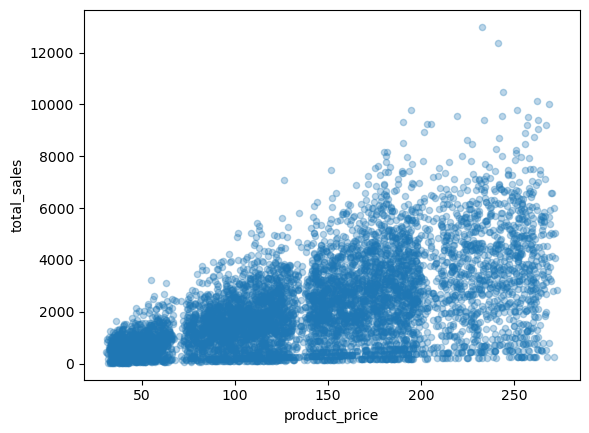

In [33]:
train.plot.scatter(x='product_price', y='total_sales', alpha=0.3)

In [34]:
train.groupby(pd.cut(train['product_price'], bins=10))['total_sales'].count()

C:\Users\USER\AppData\Local\Temp\ipykernel_21152\3187544421.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train.groupby(pd.cut(train['product_price'], bins=10))['total_sales'].count()


product_price
(30.868, 55.303]       781
(55.303, 79.496]       477
(79.496, 103.689]      882
(103.689, 127.882]    1012
(127.882, 152.075]     686
(152.075, 176.268]     883
(176.268, 200.461]     922
(200.461, 224.654]     366
(224.654, 248.847]     440
(248.847, 273.04]      369
Name: total_sales, dtype: int64

In [35]:
#creating a new feature that combines store_format and store_size to check whether there is an interaction effect between the two features on total_sales
train['store_format_size'] = train['store_format'] + '_' + train['store_size']
test['store_format_size'] = test['store_format'] + '_' + test['store_size']

In [36]:
train['store_format_size'].value_counts()

store_format_size
Standard Supermarket_Small      1506
Standard Supermarket_Missing    1480
Standard Supermarket_Large       748
Flagship Hypermarket_Medium      748
Superstore_Medium                742
Standard Supermarket_Medium      728
Corner Shop_Missing              439
Corner Shop_Small                427
Name: count, dtype: int64

In [37]:
train.groupby('store_format_size')['total_sales'].agg(['mean','median','count'])

,mean,median,count
store_format_size,,,
Corner Shop_Missing,334.435011,240.320,439
Corner Shop_Small,338.326651,260.820,427
Flagship Hypermarket_Medium,3660.182219,3348.085,748
Standard Supermarket_Large,2254.890120,1998.725,748
Standard Supermarket_Medium,2365.926745,2003.490,728
Standard Supermarket_Missing,2271.995061,1936.140,1480
Standard Supermarket_Small,2366.409847,2023.655,1506
Superstore_Medium,1971.661954,1622.170,742


In [38]:
train['store_age_years'].describe()

count    6818.000000
mean       34.178205
std         8.384574
min        23.000000
25%        28.000000
50%        33.000000
75%        45.000000
max        47.000000
Name: store_age_years, dtype: float64

In [39]:
train['store_age_years'].value_counts().sort_index()

store_age_years
23     742
25     744
28     752
30     736
33     728
34     439
35     754
45     748
47    1175
Name: count, dtype: int64

In [40]:
train.groupby('store_age_years')['total_sales'].agg(['mean','median','count'])

,mean,median,count
store_age_years,,,
23,1971.661954,1622.170,742
25,2365.833656,2018.895,744
28,2479.168098,2139.320,752
30,2177.136481,1863.030,736
33,2365.926745,2003.490,728
34,334.435011,240.320,439
35,2253.950690,1902.455,754
45,2254.890120,1998.725,748
47,2453.005770,1832.110,1175


In [41]:
train[train['store_age_years'] == 34]['store_format'].value_counts()

store_format
Corner Shop    439
Name: count, dtype: int64

In [42]:
#building a baseline model


In [43]:
categorical_cols = ['fat_content', 'product_category', 'store_location_tier', 'store_format', 'store_size']
train_encoded = pd.get_dummies(train, columns=categorical_cols, drop_first=True)
test_encoded = pd.get_dummies(test, columns=categorical_cols, drop_first=True)

In [44]:
train_encoded, test_encoded = train_encoded.align(test_encoded, join='left', axis=1, fill_value=0)

In [45]:
from sklearn.model_selection import train_test_split

X = train_encoded.drop(columns=['total_sales', 'id', 'product_code', 'store_code', 'store_format_size'])
y = train_encoded['total_sales']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [46]:
from sklearn.preprocessing import StandardScaler

numeric_cols = ['product_weight_kg', 'shelf_visibility', 'product_price', 'store_age_years']

scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_val[numeric_cols] = scaler.transform(X_val[numeric_cols])

In [47]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

model = LinearRegression()
model.fit(X_train, y_train)

preds = model.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, preds))
print(f"Linear regression RMSE: {rmse}")

Linear regression RMSE: 1122.6086944074996


In [48]:
mean_pred = np.full_like(y_val, y_train.mean(), dtype=float)
mean_rmse = np.sqrt(mean_squared_error(y_val, mean_pred))
print(f"Mean-baseline RMSE: {mean_rmse}")

Mean-baseline RMSE: 1716.8662994066603


In [49]:
# Reuse train_encoded, test_encoded from earlier in this same notebook
drop_cols = ['id', 'product_code', 'store_code']
if 'store_format_size' in train_encoded.columns:
    drop_cols.append('store_format_size')

X_full = train_encoded.drop(columns=['total_sales'] + drop_cols)
y_full = train_encoded['total_sales']
X_test_final = test_encoded.drop(columns=drop_cols)

In [53]:
from sklearn.preprocessing import StandardScaler

numeric_cols = ['product_weight_kg', 'shelf_visibility', 'product_price', 'store_age_years']

scaler_final = StandardScaler()
X_full[numeric_cols] = scaler_final.fit_transform(X_full[numeric_cols])
X_test_final = test_encoded.drop(columns=drop_cols + ['total_sales'])

In [54]:
from sklearn.linear_model import LinearRegression

final_model = LinearRegression()
final_model.fit(X_full, y_full)

test_predictions = final_model.predict(X_test_final)

In [55]:
set(X_full.columns) == set(X_test_final.columns)

True

In [56]:
submission = pd.DataFrame({
    'ID': test['id'],
    'total_sales': test_predictions
})

submission.to_csv('submission_linear_baseline.csv', index=False)

In [58]:
print(submission.head())
print(submission.shape)
print(sample_submission.shape)  # row counts should match

# Check for any negative predictions (shouldn't happen with sales)
print((submission['total_sales'] < 0).sum())

          ID    total_sales
0  row_00009  178443.888657
1  row_00015  245223.925857
2  row_00019   99478.202226
3  row_00020  186611.209499
4  row_00023  137964.241719
(1705, 2)
(1705, 2)
0
